In [ ]:
from google.colab import files
uploaded=files.upload()

Saving breast-cancer.csv to breast-cancer.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data=pd.read_csv("breast-cancer.csv")
df=pd.DataFrame(data)
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.drop(['id'],inplace=True,axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [ ]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
x=df.drop(['diagnosis'],axis=1)
y=df['diagnosis']


In [ ]:
x.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
for i in range(1,30):
  kn1=KNeighborsClassifier(n_neighbors=i)
  kn1.fit(x_train,y_train)
  print(i,kn1.score(x_train,y_train)*100,kn1.score(x_test,y_test)*100)

1 100.0 93.85964912280701
2 97.14285714285714 94.73684210526315
3 98.46153846153847 94.73684210526315
4 96.7032967032967 95.6140350877193
5 98.02197802197801 94.73684210526315
6 96.92307692307692 95.6140350877193
7 96.92307692307692 94.73684210526315
8 96.7032967032967 95.6140350877193
9 97.8021978021978 96.49122807017544
10 97.14285714285714 95.6140350877193
11 97.58241758241758 95.6140350877193
12 96.92307692307692 95.6140350877193
13 97.36263736263736 95.6140350877193
14 96.26373626373626 95.6140350877193
15 96.7032967032967 95.6140350877193
16 96.04395604395604 94.73684210526315
17 96.7032967032967 94.73684210526315
18 96.04395604395604 94.73684210526315
19 96.26373626373626 94.73684210526315
20 95.82417582417582 94.73684210526315
21 95.82417582417582 94.73684210526315
22 95.16483516483515 94.73684210526315
23 95.82417582417582 94.73684210526315
24 94.94505494505493 94.73684210526315
25 95.38461538461539 94.73684210526315
26 95.38461538461539 94.73684210526315
27 95.6043956043956 9

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train,y_train=smote.fit_resample(x_train,y_train)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=8)
knn.fit(x_train,y_train)


KNeighborsClassifier(n_neighbors=8)

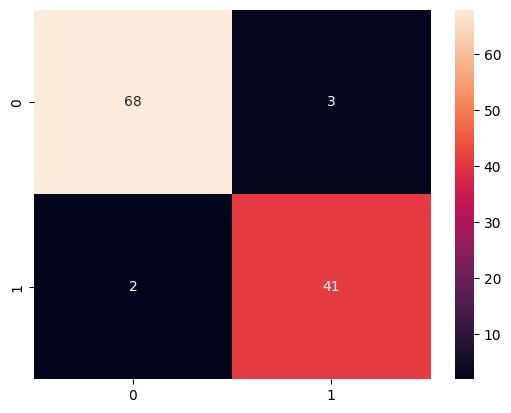

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred=knn.predict(x_test)
cf=confusion_matrix(y_test,y_pred)
sns.heatmap(cf,annot=True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print(accuracy_score(y_test,y_pred)*100)
print(precision_score(y_test,y_pred, pos_label='M')*100)
print(recall_score(y_test,y_pred, pos_label='M')*100)
print(f1_score(y_test,y_pred, pos_label='M')*100)

95.6140350877193
93.18181818181817
95.34883720930233
94.25287356321839


In [ ]:
#'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
#'smoothness_mean', 'compactness_mean', 'concavity_mean',
       #'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       #'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       #'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       #'fractal_dimension_se', 'radius_worst', 'texture_worst',
       #'perimeter_worst', 'area_worst', 'smoothness_worst',
       #'compactness_worst', 'concavity_worst', 'concave points_worst',
       #'symmetry_worst', 'fractal_dimension_worst'
import numpy as np
rm=float(input("Enter the radius mean :"))
tm=float(input("Enter the texture mean :"))
pm=float(input("Enter the perimeter mean :"))
am=float(input("Enter the area mean :"))
sm=float(input("Enter the smoothness mean :"))
cm=float(input("Enter the compactness mean :"))
ccm=float(input("Enter the concavity mean :"))
cpm=float(input("Enter the concave points mean :"))
symm=float(input("Enter the symmetry mean :"))
fdm=float(input("Enter the fractal dimension mean :"))
rse=float(input("Enter the radius se :"))
tse=float(input("Enter the texture se :"))
pse=float(input("Enter the perimeter se :"))
ase=float(input("Enter the area se :"))
sese=float(input("Enter the smoothness se :"))
cse=float(input("Enter the compactness se :"))
ccse=float(input("Enter the concavity se :"))
ccpse=float(input("Enter the concave points se :"))
symse=float(input("Enter the symmetry se :"))
fdse=float(input("Enter the fractal dimension se :"))
rw=float(input("Enter the radius worst:"))
tworst=float(input("Enter the texture worst:"))
pworst=float(input("Enter the perimeter worst:"))
aworst=float(input("Enter the area worst:"))
sworst=float(input("Enter the smoothness worst:"))
cworst=float(input("Enter the compactness worst:"))
conworst=float(input("Enter the concavity worst :"))
ccpworst=float(input("Enter the concave points worst :"))
symmworst=float(input("Enter the symmetry worst :"))
fdworst=float(input("Enter the fractal dimension worst :"))
input_data=np.array([[rm,tm,pm,am,sm,cm,ccm,cpm,symm,fdm,rse,tse,pse,ase,sese,cse,ccse,ccpse,symse,fdse,rw,tworst,pworst,aworst,sworst,cworst,conworst,ccpworst,symmworst,fdworst]])
scaled_data=scaler.transform(input_data)
prediction=knn.predict(scaled_data)
if prediction=='M':
  prediction='Malignant'
else:
  prediction='Benign'
print("The cancer will be:", prediction)

Enter the radius mean :17.99
Enter the texture mean :10.38
Enter the perimeter mean :122.80
Enter the area mean :1001.0
Enter the smoothness mean :0.1184
Enter the compactness mean :0.2776
Enter the concavity mean :0.3001
Enter the concave points mean :0.1471
Enter the symmetry mean :0.2419
Enter the fractal dimension mean :0.07871
Enter the radius se :1.0950
Enter the texture se :0.9053
Enter the perimeter se :8.5890
Enter the area se :153.40
Enter the smoothness se :0.006399
Enter the compactness se :0.04904
Enter the concavity se :0.05373
Enter the concave points se :0.01587
Enter the symmetry se :0.03003
Enter the fractal dimension se :0.006193
Enter the radius worst:25.38
Enter the texture worst:17.33
Enter the perimeter worst:184.60
Enter the area worst:2019.0
Enter the smoothness worst:0.1622
Enter the compactness worst:0.6656
Enter the concavity worst :0.7119
Enter the concave points worst :0.2654
Enter the symmetry worst :0.4601
Enter the fractal dimension worst :0.1189
The ca

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
